# Beta effect, relative vorticity, and eddy tilt

This notebook tests whether the EAC eddy dataset contains a linked sequence of signatures expected from the planetary beta effect:

1. anticyclonic eddies (AEs) propagate equatorward and cyclonic eddies (CEs) propagate poleward;
2. the observed relative-vorticity tendency is compatible with $d\zeta/dt \approx -\beta v_y$;
3. within a given eddy, weaker $|\zeta|$ is associated with greater tilt magnitude;
4. vorticity weakening precedes tilt growth; and
5. the meridional tilt component has the polarity-dependent direction expected from beta drift.

`w` is treated as core relative vorticity $\zeta$. Results are observational evidence of consistency with beta dynamics, not proof that beta causes tilt. Background EAC flow, topographic PV gradients, stretching, eddy interactions, age, and fitting uncertainty remain alternative explanations.\
![Description](beta_effect_info.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from statsmodels.genmod.cov_struct import Exchangeable, Independence
from statsmodels.genmod.families import Gaussian

import seacofs_tilt_tools as tilt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
N_BOOT = 2000
SMOOTH_DAYS = 5
LAGS_DAYS = (0, 5, 10, 20)
SECONDS_PER_DAY = 86400.0
KM_TO_M = 1000.0


## 1. Load and prepare the eddy-day table

The analysis uses central numerical derivatives after a short centred rolling median. This reduces day-to-day centre-fit noise without imposing a long dynamical timescale. Derivatives are not evaluated across gaps larger than twice the smoothing window. Bearings follow the existing convention: 0° is north and 90° is east. In the model-grid coordinates, `yc` increases approximately northward.


In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)

required = {"Eddy", "Day", "Cyc", "xc", "yc", "w", "Rc", "TiltDis", "TiltDir"}
missing = sorted(required.difference(df_eddies.columns))
if missing:
    raise KeyError(f"Missing required columns: {missing}")
if df_eddies.duplicated(["Eddy", "Day"]).any():
    raise ValueError("Expected one row per Eddy-Day before calculating tendencies.")

# Adds local f, beta, h, and shallow-water PV-gradient diagnostics.
df = tilt.add_pv_gradient_terms(df_eddies, grid)

# consider only plantery beta eddies
df = df[df.topo_plan_ratio<0].copy()

df = df.sort_values(["Eddy", "Day"]).copy()
df["Cyc"] = df["Cyc"].astype("string")
df = df[df["Cyc"].isin(["AE", "CE"])].copy()
df["age_days"] = df["Day"] - df.groupby("Eddy")["Day"].transform("min")
df["lifetime_days"] = df.groupby("Eddy")["Day"].transform(lambda x: x.max() - x.min())
df["norm_age"] = df["age_days"] / df["lifetime_days"].replace(0, np.nan)

display(pd.DataFrame({
    cyc: {"eddy_days": len(part), "eddies": part.Eddy.nunique(),
          "tilt_days": part.TiltDis.notna().sum()}
    for cyc, part in df.groupby("Cyc")
}).T)


,eddy_days,eddies,tilt_days
AE,13544,903,11918
CE,3239,706,2765


In [3]:
def smooth_and_rate(part, column, smooth_days=SMOOTH_DAYS):
    """Centred rolling-median value and time derivative per day."""
    part = part.sort_values("Day")
    time = part["Day"].to_numpy(float)
    value = part[column].astype(float)
    smooth = value.rolling(smooth_days, center=True, min_periods=3).median().to_numpy()
    rate = np.full(len(part), np.nan)
    valid = np.isfinite(time) & np.isfinite(smooth)
    if valid.sum() >= 3 and np.all(np.diff(time[valid]) > 0):
        rate[valid] = np.gradient(smooth[valid], time[valid])
        valid_pos = np.flatnonzero(valid)
        for pos in valid_pos:
            neighbours = []
            if pos > 0 and valid[pos - 1]:
                neighbours.append(time[pos] - time[pos - 1])
            if pos + 1 < len(part) and valid[pos + 1]:
                neighbours.append(time[pos + 1] - time[pos])
            if not neighbours or max(neighbours) > 2 * smooth_days:
                rate[pos] = np.nan
    return pd.DataFrame({f"{column}_smooth": smooth, f"d{column}_day": rate}, index=part.index)

for column in ("xc", "yc", "w", "TiltDis"):
    derived = pd.concat(
        [smooth_and_rate(part, column) for _, part in df.groupby("Eddy", sort=False)]
    ).sort_index()
    df = df.join(derived)

df["prop_east_km_day"] = df["dxc_day"]
df["prop_north_km_day"] = df["dyc_day"]
df["prop_north_m_s"] = df["prop_north_km_day"] * KM_TO_M / SECONDS_PER_DAY
df["dw_dt"] = df["dw_day"] / SECONDS_PER_DAY
df["beta_vorticity_tendency"] = -df["beta"] * df["prop_north_m_s"]
df["budget_residual"] = df["dw_dt"] - df["beta_vorticity_tendency"]
df["abs_w"] = df["w"].abs()
df["dabs_w_day"] = np.sign(df["w_smooth"]) * df["dw_day"]

theta = np.deg2rad(df["TiltDir"].astype(float))
df["tilt_north_km"] = df["TiltDis"] * np.cos(theta)
df["tilt_east_km"] = df["TiltDis"] * np.sin(theta)
df["expected_meridional_sign"] = df["Cyc"].map({"AE": 1.0, "CE": -1.0}).astype(float)
df["aligned_prop_km_day"] = df["expected_meridional_sign"] * df["prop_north_km_day"]
df["aligned_tilt_km"] = df["expected_meridional_sign"] * df["tilt_north_km"]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[["prop_north_km_day", "dw_dt", "beta_vorticity_tendency", "TiltDis", "w"]].describe()


,prop_north_km_day,dw_dt,beta_vorticity_tendency,TiltDis,w
count,14853.000000,1.485300e+04,1.485300e+04,14683.000000,16783.000000
mean,-1.601895,2.758953e-13,-3.519996e-13,19.468724,0.000023
std,6.478829,1.619189e-11,1.443099e-12,18.348536,0.000026
min,-162.479765,-2.386986e-10,-3.895347e-11,0.010263,-0.000087
25%,-3.556949,-4.466291e-12,-7.723035e-13,7.434326,0.000013
50%,-0.560338,0.000000e+00,-1.221640e-13,13.865040,0.000027
75%,0.601909,4.891219e-12,1.305594e-13,25.267482,0.000039
max,62.135931,1.804906e-10,1.368847e-11,266.951190,0.000097


## 2. Primary beta-effect signature: divergent meridional pathways

The primary prediction is positive northward propagation for Southern Hemisphere AEs (equatorward) and negative northward propagation for CEs (poleward). Each eddy contributes one median propagation value, so long tracks do not dominate. Confidence intervals resample complete eddies.


,n_eddies,estimate,CI_low,CI_high,expected_direction_fraction
Cyc,,,,,
AE,663.0,-0.444,-0.618,-0.206,0.173
CE,380.0,-0.051,-0.207,0.000,0.283


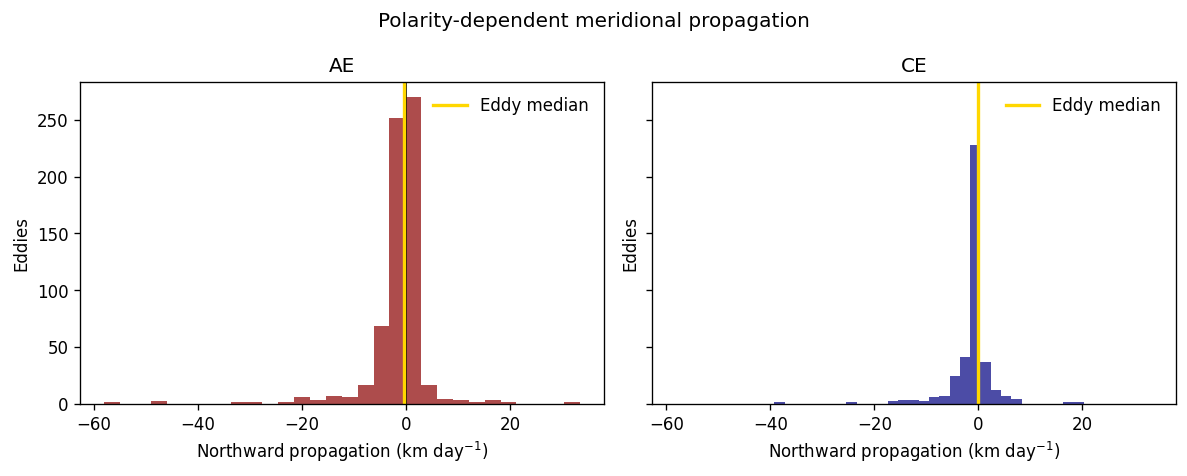

In [4]:
def bootstrap_eddy_stat(values, statistic=np.nanmedian, n_boot=N_BOOT, seed=RANDOM_STATE):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    rng = np.random.default_rng(seed)
    boot = np.array([statistic(rng.choice(values, len(values), replace=True)) for _ in range(n_boot)])
    return pd.Series({"n_eddies": len(values), "estimate": statistic(values),
                      "CI_low": np.nanpercentile(boot, 2.5),
                      "CI_high": np.nanpercentile(boot, 97.5)})

eddy_tracks = (df.groupby(["Cyc", "Eddy"], as_index=False)
                 .agg(prop_north=("prop_north_km_day", "median"),
                      aligned_prop=("aligned_prop_km_day", "median"),
                      lat_change=("yc", lambda x: x.iloc[-1] - x.iloc[0]),
                      lifetime_days=("lifetime_days", "first"),
                      Rc=("Rc", "median"), abs_w=("abs_w", "median")))

pathway_results = []
for offset, cyc in enumerate(("AE", "CE")):
    part = eddy_tracks[eddy_tracks.Cyc == cyc]
    result = bootstrap_eddy_stat(part["prop_north"], seed=RANDOM_STATE + offset)
    result["Cyc"] = cyc
    result["expected_direction_fraction"] = np.mean(part["aligned_prop"] > 0)
    pathway_results.append(result)
pathway_results = pd.DataFrame(pathway_results).set_index("Cyc")
display(pathway_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, cyc, color in zip(axes, ("AE", "CE"), ("darkred", "navy")):
    values = eddy_tracks.loc[eddy_tracks.Cyc == cyc, "prop_north"].dropna()
    ax.hist(values, bins=30, color=color, alpha=0.7)
    ax.axvline(0, color="k", lw=1)
    ax.axvline(values.median(), color="gold", lw=2, label="Eddy median")
    ax.set(title=cyc, xlabel="Northward propagation (km day$^{-1}$)", ylabel="Eddies")
    ax.legend(frameon=False)
fig.suptitle("Polarity-dependent meridional propagation")
fig.tight_layout()


## 3. Relative-vorticity budget

For approximate conservation of absolute vorticity, $d\zeta/dt \approx -\beta v_y$. Both terms below have units s$^{-2}$. A fitted slope near one and intercept near zero are the simplest quantitative expectation, although stretching and other PV processes mean exact closure is not expected. The comparison is made separately by polarity with eddy-clustered robust uncertainty.


,rows,eddies,slope,slope_CI_low,slope_CI_high,intercept_scaled
Cyc,,,,,,
AE,12453,663,-1.149,-1.707,-0.592,-0.656
CE,2400,380,-1.948,-3.200,-0.696,2.096


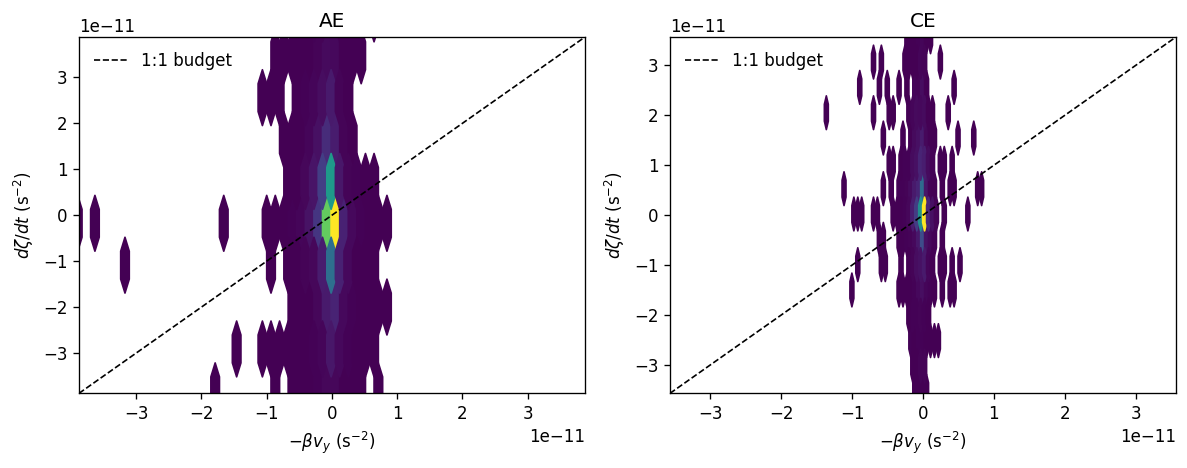

In [5]:
budget_models = {}
budget_rows = []
for cyc in ("AE", "CE"):
    part = df.loc[df.Cyc == cyc, ["Eddy", "dw_dt", "beta_vorticity_tendency"]].dropna().copy()
    scale = np.nanstd(part["beta_vorticity_tendency"])
    part["dw_scaled"] = part["dw_dt"] / scale
    part["beta_scaled"] = part["beta_vorticity_tendency"] / scale
    result = smf.gee("dw_scaled ~ beta_scaled", groups="Eddy", data=part,
                     cov_struct=Exchangeable(), family=Gaussian()).fit()
    budget_models[cyc] = result
    budget_rows.append({"Cyc": cyc, "rows": len(part), "eddies": part.Eddy.nunique(),
                        "slope": result.params["beta_scaled"],
                        "slope_CI_low": result.conf_int().loc["beta_scaled", 0],
                        "slope_CI_high": result.conf_int().loc["beta_scaled", 1],
                        "intercept_scaled": result.params["Intercept"]})
display(pd.DataFrame(budget_rows).set_index("Cyc").round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cyc, color in zip(axes, ("AE", "CE"), ("darkred", "navy")):
    part = df[df.Cyc == cyc].dropna(subset=["dw_dt", "beta_vorticity_tendency"])
    limit = np.nanpercentile(np.abs(np.r_[part.dw_dt, part.beta_vorticity_tendency]), 98)
    ax.hexbin(part.beta_vorticity_tendency, part.dw_dt, gridsize=40, mincnt=1, cmap="viridis")
    ax.plot([-limit, limit], [-limit, limit], "k--", lw=1, label="1:1 budget")
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), title=cyc,
           xlabel=r"$-\beta v_y$ (s$^{-2}$)", ylabel=r"$d\zeta/dt$ (s$^{-2}$)")
    ax.legend(frameon=False)
fig.tight_layout()


## 4. Does vorticity weakening accompany greater tilt?

`abs_w_between` asks whether characteristically weaker eddies are more tilted than characteristically stronger eddies. `abs_w_within` asks the more relevant repeated-measures question: when the same eddy is weaker than its own mean state, is it more tilted? Age, radius, bathymetry, and local beta magnitude are included as adjustment terms. Continuous terms are standardised within each polarity.


In [6]:
association_models = {}
association_rows = []
association_data = {}
for cyc in ("AE", "CE"):
    part = df[df.Cyc == cyc].copy()
    part["log_tilt"] = np.log1p(part["TiltDis"].clip(lower=0))
    part["abs_w_between"] = part.groupby("Eddy")["abs_w"].transform("mean")
    part["abs_w_within"] = part["abs_w"] - part["abs_w_between"]
    part["abs_beta"] = part["beta"].abs()
    for column in ("abs_w_between", "abs_w_within", "age_days", "Rc", "h", "abs_beta"):
        sd = part[column].std()
        part[f"{column}_z"] = (part[column] - part[column].mean()) / (sd if np.isfinite(sd) and sd > 0 else 1.0)
    needed = ["Eddy", "log_tilt", "abs_w_between_z", "abs_w_within_z",
              "age_days_z", "Rc_z", "h_z", "abs_beta_z"]
    fit = part[needed].dropna().copy()
    result = smf.gee(
        "log_tilt ~ abs_w_between_z + abs_w_within_z + age_days_z + Rc_z + h_z + abs_beta_z",
        groups="Eddy", data=fit, cov_struct=Exchangeable(), family=Gaussian()
    ).fit()
    association_models[cyc] = result
    association_data[cyc] = part
    ci = result.conf_int()
    for term in ("abs_w_between_z", "abs_w_within_z"):
        association_rows.append({"Cyc": cyc, "term": term, "coefficient_log1p_tilt": result.params[term],
                                 "CI_low": ci.loc[term, 0], "CI_high": ci.loc[term, 1],
                                 "p_value": result.pvalues[term], "rows": len(fit),
                                 "eddies": fit.Eddy.nunique()})
display(pd.DataFrame(association_rows).set_index(["Cyc", "term"]).round(4))

# Working-correlation sensitivity: coefficients should remain compatible.
sensitivity = []
for cyc, part in association_data.items():
    fit = part[["Eddy", "log_tilt", "abs_w_between_z", "abs_w_within_z",
                "age_days_z", "Rc_z", "h_z", "abs_beta_z"]].dropna()
    result = smf.gee(
        "log_tilt ~ abs_w_between_z + abs_w_within_z + age_days_z + Rc_z + h_z + abs_beta_z",
        groups="Eddy", data=fit, cov_struct=Independence(), family=Gaussian()
    ).fit()
    sensitivity.append({"Cyc": cyc, "between_exchangeable": association_models[cyc].params["abs_w_between_z"],
                        "between_independence": result.params["abs_w_between_z"],
                        "within_exchangeable": association_models[cyc].params["abs_w_within_z"],
                        "within_independence": result.params["abs_w_within_z"]})
display(pd.DataFrame(sensitivity).set_index("Cyc").round(4))


coefficient_log1p_tilt  CI_low  CI_high  p_value   rows  \
Cyc term                                                                       
AE  abs_w_between_z                 -0.0962 -0.1392  -0.0532   0.0000  11918   
    abs_w_within_z                  -0.0399 -0.0711  -0.0087   0.0122  11918   
CE  abs_w_between_z                 -0.2063 -0.2594  -0.1532   0.0000   2765   
    abs_w_within_z                  -0.0484 -0.0775  -0.0193   0.0011   2765   

                     eddies  
Cyc term                     
AE  abs_w_between_z     810  
    abs_w_within_z      810  
CE  abs_w_between_z     640  
    abs_w_within_z      640

,between_exchangeable,between_independence,within_exchangeable,within_independence
Cyc,,,,
AE,-0.0962,-0.1324,-0.0399,-0.0355
CE,-0.2063,-0.2162,-0.0484,-0.0648


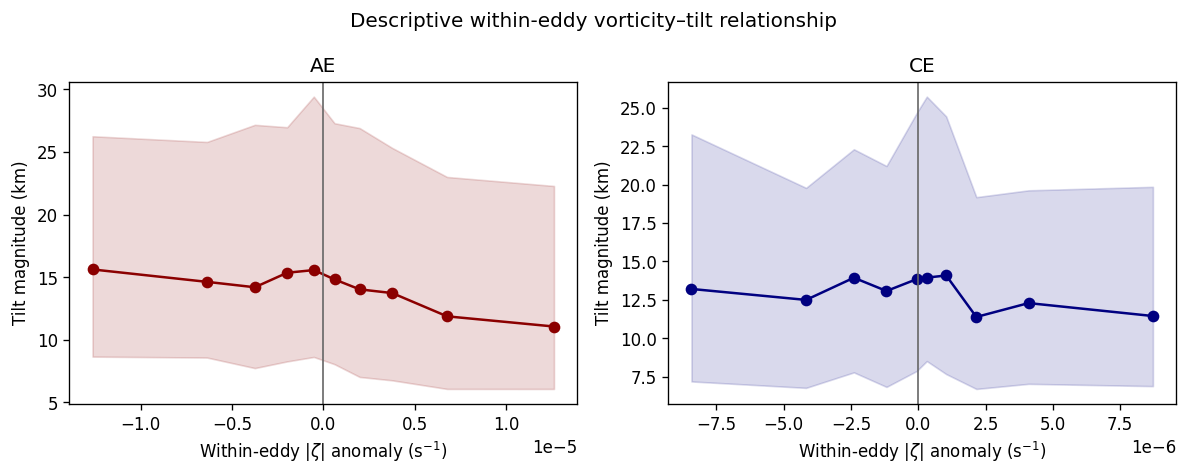

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cyc, color in zip(axes, ("AE", "CE"), ("darkred", "navy")):
    part = association_data[cyc].dropna(subset=["abs_w_within", "TiltDis"]).copy()
    part["bin"] = pd.qcut(part["abs_w_within"], 10, duplicates="drop")
    binned = part.groupby("bin", observed=True).agg(
        abs_w_anomaly=("abs_w_within", "median"), tilt=("TiltDis", "median"),
        q25=("TiltDis", lambda x: x.quantile(.25)), q75=("TiltDis", lambda x: x.quantile(.75)))
    ax.plot(binned.abs_w_anomaly, binned.tilt, "o-", color=color)
    ax.fill_between(binned.abs_w_anomaly, binned.q25, binned.q75, color=color, alpha=.15)
    ax.axvline(0, color="0.4", lw=1)
    ax.set(title=cyc, xlabel=r"Within-eddy $|\zeta|$ anomaly (s$^{-1}$)",
           ylabel="Tilt magnitude (km)")
fig.suptitle("Descriptive within-eddy vorticity–tilt relationship")
fig.tight_layout()


## 5. Temporal ordering: does weakening precede tilt growth?

For each predeclared lag, the smoothed $d|\zeta|/dt$ at day $t$ is paired with the smoothed tilt-growth rate at day $t+\tau$ using exact `Eddy`–`Day` matching. A negative coefficient is the expected direction: vorticity weakening is followed by tilt growth. Treat the lag pattern as exploratory dynamical evidence; do not select only the smallest p-value.


coefficient  CI_low  CI_high  p_value   rows  eddies
Cyc lag_days                                                      
AE  0             -0.1623 -0.2752  -0.0493   0.0049  10971     580
    5             -0.0528 -0.1604   0.0547   0.3355   6498     430
    10            -0.0288 -0.1660   0.1085   0.6809   5399     381
    20             0.0258 -0.0839   0.1355   0.6449   4018     268
CE  0             -0.1333 -0.2765   0.0100   0.0683   2037     328
    5             -0.2086 -0.4116  -0.0057   0.0439    532     183
    10             0.0224 -0.1084   0.1532   0.7369    353     133
    20             0.0568 -0.1549   0.2685   0.5992    128      59

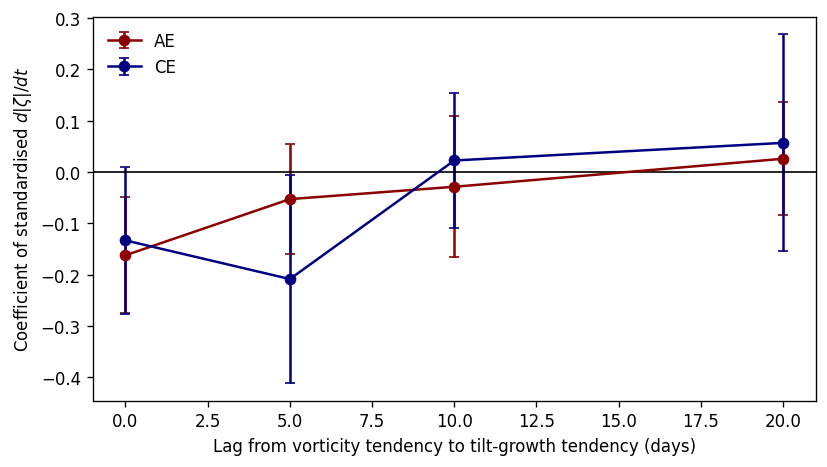

In [8]:
lag_rows = []
lag_models = {}
future_source = df[["Eddy", "Day", "dTiltDis_day"]].copy()
for cyc in ("AE", "CE"):
    base = df[df.Cyc == cyc].copy()
    for lag in LAGS_DAYS:
        future = future_source.rename(columns={"Day": "future_day", "dTiltDis_day": "future_tilt_growth"})
        paired = base.assign(future_day=base["Day"] + lag).merge(future, on=["Eddy", "future_day"], how="left")
        fit = paired[["Eddy", "dabs_w_day", "future_tilt_growth", "age_days", "Rc", "h"]].dropna().copy()
        for column in ("dabs_w_day", "age_days", "Rc", "h"):
            sd = fit[column].std()
            fit[f"{column}_z"] = (fit[column] - fit[column].mean()) / (sd if np.isfinite(sd) and sd > 0 else 1.0)
        result = smf.gee("future_tilt_growth ~ dabs_w_day_z + age_days_z + Rc_z + h_z",
                         groups="Eddy", data=fit, cov_struct=Exchangeable(), family=Gaussian()).fit()
        lag_models[(cyc, lag)] = result
        ci = result.conf_int().loc["dabs_w_day_z"]
        lag_rows.append({"Cyc": cyc, "lag_days": lag, "coefficient": result.params["dabs_w_day_z"],
                         "CI_low": ci.iloc[0], "CI_high": ci.iloc[1],
                         "p_value": result.pvalues["dabs_w_day_z"],
                         "rows": len(fit), "eddies": fit.Eddy.nunique()})
lag_results = pd.DataFrame(lag_rows)
display(lag_results.set_index(["Cyc", "lag_days"]).round(4))

fig, ax = plt.subplots(figsize=(7, 4))
for cyc, color in (("AE", "darkred"), ("CE", "navy")):
    part = lag_results[lag_results.Cyc == cyc]
    ax.errorbar(part.lag_days, part.coefficient,
                yerr=[part.coefficient - part.CI_low, part.CI_high - part.coefficient],
                marker="o", capsize=3, color=color, label=cyc)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="Lag from vorticity tendency to tilt-growth tendency (days)",
       ylabel=r"Coefficient of standardised $d|\zeta|/dt$")
ax.legend(frameon=False)
fig.tight_layout()


## 6. Meridional propagation and tilt alignment

Positive `aligned_prop` and `aligned_tilt` mean equatorward for AEs and poleward for CEs. This section checks the direct bridge between the propagation prediction and the observed vertical geometry. Eddy-level results avoid pseudo-replication; the repeated-measures GEE distinguishes differences among eddies from day-to-day covariation within an eddy.


In [9]:
eddy_alignment = (df.groupby(["Cyc", "Eddy"], as_index=False)
                   .agg(aligned_prop=("aligned_prop_km_day", "median"),
                        aligned_tilt=("aligned_tilt_km", "median"),
                        tilt_magnitude=("TiltDis", "median")))
alignment_rows = []
for cyc in ("AE", "CE"):
    part = eddy_alignment[eddy_alignment.Cyc == cyc].dropna()
    rho = spearmanr(part.aligned_prop, part.aligned_tilt).statistic
    rng = np.random.default_rng(RANDOM_STATE + (cyc == "CE"))
    boot = []
    for _ in range(N_BOOT):
        sample = part.iloc[rng.integers(0, len(part), len(part))]
        boot.append(spearmanr(sample.aligned_prop, sample.aligned_tilt).statistic)
    alignment_rows.append({"Cyc": cyc, "eddies": len(part),
                           "fraction_tilt_expected_direction": np.mean(part.aligned_tilt > 0),
                           "spearman_prop_vs_tilt": rho,
                           "CI_low": np.nanpercentile(boot, 2.5),
                           "CI_high": np.nanpercentile(boot, 97.5)})
display(pd.DataFrame(alignment_rows).set_index("Cyc").round(3))

direction_models = {}
for cyc in ("AE", "CE"):
    part = df[df.Cyc == cyc].copy()
    part["prop_between"] = part.groupby("Eddy")["aligned_prop_km_day"].transform("mean")
    part["prop_within"] = part["aligned_prop_km_day"] - part["prop_between"]
    for column in ("prop_between", "prop_within", "age_days", "Rc"):
        sd = part[column].std()
        part[f"{column}_z"] = (part[column] - part[column].mean()) / (sd if np.isfinite(sd) and sd > 0 else 1.0)
    fit = part[["Eddy", "aligned_tilt_km", "prop_between_z", "prop_within_z", "age_days_z", "Rc_z"]].dropna()
    result = smf.gee("aligned_tilt_km ~ prop_between_z + prop_within_z + age_days_z + Rc_z",
                     groups="Eddy", data=fit, cov_struct=Exchangeable(), family=Gaussian()).fit()
    direction_models[cyc] = result
    print(cyc)
    display(pd.DataFrame({"coefficient": result.params, "p_value": result.pvalues,
                          "CI_low": result.conf_int()[0], "CI_high": result.conf_int()[1]}).round(4))


,eddies,fraction_tilt_expected_direction,spearman_prop_vs_tilt,CI_low,CI_high
Cyc,,,,,
AE,648,0.690,-0.122,-0.196,-0.047
CE,374,0.767,0.001,-0.099,0.100


AE


,coefficient,p_value,CI_low,CI_high
Intercept,6.8782,0.0000,5.7022,8.0542
prop_between_z,-2.0320,0.0021,-3.3271,-0.7370
prop_within_z,-2.6814,0.0000,-3.3712,-1.9915
age_days_z,-1.1713,0.0222,-2.1751,-0.1674
Rc_z,1.0514,0.0514,-0.0065,2.1094


CE


,coefficient,p_value,CI_low,CI_high
Intercept,8.2679,0.0000,6.9761,9.5597
prop_between_z,-0.3572,0.5438,-1.5104,0.7960
prop_within_z,0.0262,0.9456,-0.7260,0.7783
age_days_z,-0.0278,0.9534,-0.9606,0.9050
Rc_z,0.2412,0.7709,-1.3823,1.8646


## 7. Age and environment sensitivity

Morrow et al. found vorticity decay mainly during the first three months of warm Leeuwin Current eddies, and stressed that simple beta-plane propagation is clearest in weak background flow. Repeat the key summaries below for early/late life, large eddies, and any available region labels. These are sensitivity analyses rather than opportunities to select the most favourable subgroup.


In [10]:
df["age_stage"] = pd.cut(df["age_days"], [-np.inf, 90, np.inf], labels=["first_90_days", "later"])
df["size_stage"] = pd.cut(df["Rc"], [-np.inf, 50, 100, np.inf],
                              labels=["Rc_<50_km", "Rc_50-100_km", "Rc_>100_km"])
sensitivity_summary = (df.groupby(["Cyc", "age_stage", "size_stage"], observed=True)
                       .agg(rows=("Eddy", "size"), eddies=("Eddy", "nunique"),
                            median_aligned_prop=("aligned_prop_km_day", "median"),
                            median_abs_w_tendency=("dabs_w_day", "median"),
                            median_aligned_tilt=("aligned_tilt_km", "median")))
display(sensitivity_summary)

if "RegionGroup" in df.columns:
    display(df.groupby(["Cyc", "RegionGroup"])
            .agg(rows=("Eddy", "size"), eddies=("Eddy", "nunique"),
                 aligned_prop=("aligned_prop_km_day", "median"),
                 aligned_tilt=("aligned_tilt_km", "median")))
else:
    print("RegionGroup is not present. Add region labels before loading this notebook if an EAC/offshore sensitivity is required.")


rows  eddies  median_aligned_prop  \
Cyc age_stage     size_stage                                        
AE  first_90_days Rc_<50_km     1483     312            -0.620443   
                  Rc_50-100_km  4964     605            -0.549066   
                  Rc_>100_km    4787     348            -1.040615   
    later         Rc_<50_km       80      16            -0.651181   
                  Rc_50-100_km  1359      44             0.000000   
                  Rc_>100_km     871      40            -0.543071   
CE  first_90_days Rc_<50_km      539     192             0.019627   
                  Rc_50-100_km  1845     475             0.297963   
                  Rc_>100_km     802     201             0.285286   
    later         Rc_50-100_km    44       9             0.151534   
                  Rc_>100_km       9       6             4.168847   

                                median_abs_w_tendency  median_aligned_tilt  
Cyc age_stage     size_stage                                                
AE  first_90_days Rc_<50_km             -6.435299e-08             4.164522  
                  Rc_50-100_km           0.000000e+00             5.005956  
                  Rc_>100_km             0.000000e+00             6.468694  
    later         Rc_<50_km             -2.964615e-21             0.704535  
                  Rc_50-100_km          -1.440757e-08             1.400918  
                  Rc_>100_km             0.000000e+00             3.907682  
CE  first_90_days Rc_<50_km             -1.094365e-07             4.867854  
                  Rc_50-100_km          -5.399484e-08             4.384200  
                  Rc_>100_km            -0.000000e+00             8.710350  
    later         Rc_50-100_km          -1.943900e-08             5.053085  
                  Rc_>100_km             6.905296e-07             2.779928

RegionGroup is not present. Add region labels before loading this notebook if an EAC/offshore sensitivity is required.


## 8. Interpretation checklist

Evidence is strongest if all of the following agree:

- AE eddy-level northward propagation is positive and CE propagation is negative, with useful bootstrap intervals and a majority of eddies in the expected direction.
- The vorticity-budget slope is positive and plausibly near one; the result is not merely driven by a few extreme derivatives.
- `abs_w_within_z` has a negative association with tilt magnitude: the same eddy is more tilted when its relative-vorticity magnitude is weaker.
- Negative $d|\zeta|/dt$ precedes positive tilt growth over a physically plausible lag, with compatible results across the predeclared lags.
- Meridional propagation and meridional tilt align in the polarity-expected direction, both between eddies and within eddies.
- Results remain qualitatively compatible across age, radius, region, and GEE working-correlation sensitivities.

A clear propagation signature with near-constant core `w` is still compatible with Morrow et al.; most of their long-lived eddies did not show strong core-vorticity decay. Conversely, a vorticity–tilt association without polarity-dependent drift is not strong evidence for the beta effect. Report effect sizes, confidence intervals, eddy counts, and sensitivity patterns—not p-values alone.
